In [2]:
# Import python libraries
#import json
import os
import pathlib
from glob import glob

import earthpy.api.appeears as eaapp
import earthpy
import geopandas as gpd
import hvplot.pandas
import hvplot.xarray
import pandas as pd
import rioxarray as rxr
import xarray as xr
import holoviews as hv
import matplotlib.pyplot as plt
import osmnx as osm

# Look at San Carlos Apache Reservation

In [3]:
# Search OSM for San Carlos Apache using geocode_to_gdf
osm_way_id = 9436141

# Retrieve polygon boundary
scat_boundary = osm.geocode_to_gdf(
    "R9436141",
    by_osmid=True
)

scat_boundary

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"MULTIPOLYGON (((-110.75277 33.17056, -110.7506...",-110.752774,32.875137,-109.495406,33.817328,333989162,relation,9436141,33.335742,-110.109503,boundary,aboriginal_lands,25,0.066677,aboriginal_lands,San Carlos Apache Indian Reservation,"San Carlos Apache Indian Reservation, Arizona,..."


<Axes: >

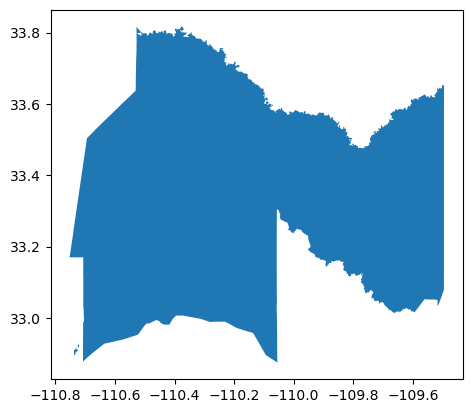

In [3]:
scat_boundary.plot()

In [9]:
# Create a project for file management
project = earthpy.Project(
    "San Carlos Vegetation",
    dirname="scat-vegetation"
)

In [10]:
# Initialize AppeearsDownloader for MODIS NDVI data
ndvi_downloader = eaapp.AppeearsDownloader(
    download_key='scat',
    project=project,
    product='MOD13Q1.061',
    layer='_250m_16_days_NDVI',
    start_date="06-01",
    end_date="09-01",
    recurring=True,
    year_range=[2015, 2025],
    polygon=scat_boundary
)

In [11]:
# Download the prepared download -- this can take some time!
ndvi_downloader.download_files(cache=False)

Credentials found using 'env' backend.


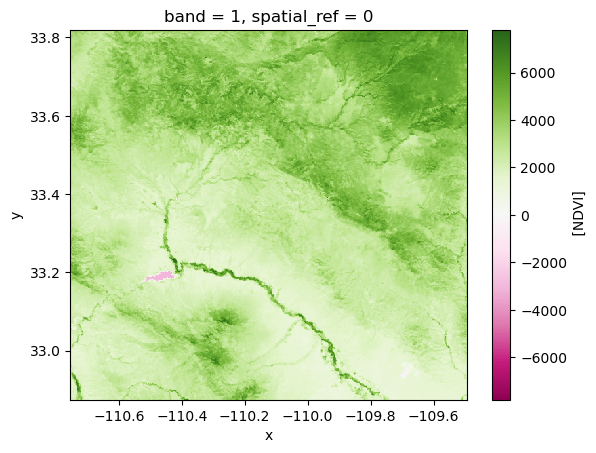

In [5]:
# Open the GeoTIFF
tif_path = "/workspaces/data/scat-vegetation/scat/MOD13Q1.061_2015137_to_2025244/MOD13Q1.061__250m_16_days_NDVI_doy2015145000000_aid0001.tif"

raster = rxr.open_rasterio(tif_path)

# Plot
raster.plot(cmap="PiYG")

plt.show()

In [7]:
# Get list of NDVI tif file paths
ndvi_paths = sorted(glob(os.path.join(
    '/workspaces/data/scat-vegetation/scat', '**', '*NDVI*.tif')))
f'{len(ndvi_paths)} NDVI paths found'

'77 NDVI paths found'

In [ ]:
from pathlib import Path

doy_start = -25
doy_end = -19

# Loop through each NDVI image
ndvi_das_dl = []
for ndvi_path in ndvi_paths:
    ndvi_path = Path(ndvi_path)

    # Get date from file name
    doy = ndvi_path.name[doy_start:doy_end]
    date = pd.to_datetime(doy, format='%Y%j')

    # Open dataset
    da = rxr.open_rasterio(ndvi_path, mask_and_scale=True).squeeze()

    # Add date dimension and clean up metadata
    da = da.assign_coords({'date': date})
    da = da.expand_dims({'date': 1})
    da.name = 'NDVI'

    # Prepare for concatenation
    ndvi_das_dl.append(da)

len(ndvi_das_dl)

77

In [9]:
# Combine NDVI images from all dates
ndvi_da = xr.combine_by_coords(ndvi_das_dl, coords=['date'])
ndvi_da

/tmp/ipykernel_10850/1684111952.py:2: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ndvi_da = xr.combine_by_coords(ndvi_das_dl, coords=['date'])
/tmp/ipykernel_10850/1684111952.py:2: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ndvi_da = xr.combine_by_coords(ndvi_das_dl, coords=['date'])


<xarray.Dataset> Size: 84MB
Dimensions:      (date: 77, y: 453, x: 605)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 5kB -110.8 -110.8 -110.7 ... -109.5 -109.5 -109.5
  * y            (y) float64 4kB 33.82 33.82 33.81 33.81 ... 32.88 32.88 32.88
    spatial_ref  int64 8B 0
  * date         (date) datetime64[ns] 616B 2015-01-14 2015-01-16 ... 2025-01-24
Data variables:
    NDVI         (date, y, x) float32 84MB 0.3729 0.3536 ... 0.1266 0.1208

In [12]:
# Calculate difference in NDVI (After water rights are restored - Before)
ndvi_diff = (
    ndvi_da
        .sel(date=slice('2020', '2025'))
        .mean('date')
        .NDVI 
   - ndvi_da
        .sel(date=slice('2015', '2020'))
        .mean('date')
        .NDVI
)
print(ndvi_diff.head())

ndvi_diff_plot = (
    ndvi_diff.hvplot(x='x', y='y', cmap='PiYG', geo=True, title='San Carlos Apache - NDVI difference: 2025-2020 minus 2020-2015')
    *
    scat_boundary.hvplot(geo=True, fill_color=None, line_color='black')
)

ndvi_diff_plot

<xarray.DataArray 'NDVI' (y: 5, x: 5)> Size: 100B
array([[-0.01915711, -0.0185715 , -0.00973567, -0.01521197, -0.0180786 ],
       [-0.01807135, -0.01318574, -0.01100716, -0.01515719, -0.022688  ],
       [-0.01331437, -0.01296425, -0.01455715, -0.0142667 , -0.0142667 ],
       [-0.01263338, -0.01350713, -0.01550481, -0.01905242, -0.01905242],
       [-0.01279527, -0.01510468, -0.01713097, -0.01713097, -0.01817137]],
      dtype=float32)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 40B -110.8 -110.8 -110.7 -110.7 -110.7
  * y            (y) float64 40B 33.82 33.82 33.81 33.81 33.81
    spatial_ref  int64 8B 0


:Overlay
   .Image.I    :Image   [x,y]   (NDVI)
   .Polygons.I :Polygons   [Longitude,Latitude]